# Engenharia de Modelos — Feature Engineering & Model Selection 🛠️

Objetivo: explorar feature engineering, selecionar as features mais relevantes, comparar múltiplos algoritmos, realizar tuning de hiperparâmetros e persistir o melhor modelo para uso no pipeline de inferência.

- **Input:** `data/processed/telco_churn_cleaned.csv`
- **Output:** `models/best_model.joblib`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.data

from scipy.stats import randint, uniform

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, ParameterSampler,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="muted")

# 📥 1. Carregamento do Dataset Pré-processado

Nesta etapa, a base de dados limpa (gerada em `02_baseline.ipynb`) será carregada e validada antes de iniciar a engenharia de features.

In [2]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

# Validacao rapida
assert "Churn Value" in df.columns, "Coluna alvo 'Churn Value' nao encontrada."
assert df.isnull().sum().sum() == 0, "Dataset contem valores nulos inesperados."

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn Value'].mean():.2%}")
df.head()


Shape: (7010, 20)
Churn rate: 26.49%


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
1,Female,0,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
2,Female,0,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1
3,Female,0,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1
4,Male,0,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1


# 🧩 2. Feature Engineering

Nesta etapa, serão criadas novas variáveis derivadas a partir das informações originais da base, com o objetivo de representar melhor o perfil e o comportamento dos clientes e fornecer sinais adicionais para os modelos.

In [3]:
df_eng = df.copy()

# --- 1. Contagem de servicos opcionais contratados ---
# Clientes com mais servicos tendem a ter maior "lock-in" e menor churn
optional_services = [
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
]
df_eng["services_count"] = df_eng[optional_services].apply(
    lambda row: (row == "Yes").sum(), axis=1
)

# --- 2. Faixa de tempo de contrato (tenure group) ---
# Captura nao-linearidade: clientes novos e veteranos se comportam diferente
df_eng["tenure_group"] = pd.cut(
    df_eng["Tenure Months"],
    bins=[-1, 12, 36, 72],
    labels=["new", "growing", "loyal"],
)

# --- 3. Custo medio mensal por mes de permanencia ---
# Razao entre mensalidade e tempo: clientes novos com planos caros = alto risco
df_eng["monthly_per_tenure"] = (
    df_eng["Monthly Charges"] / (df_eng["Tenure Months"] + 1)
)

# --- 4. Flag de protecao contratada ---
# Ter seguranca online OU protecao de dispositivo reduz churn
df_eng["has_protection"] = (
    (df_eng["Online Security"] == "Yes") |
    (df_eng["Device Protection"] == "Yes")
).astype(int)

# --- 5. Idoso sem rede de suporte familiar ---
# Perfil de alto risco identificado no EDA
# Senior Citizen é int (0/1); Partner e Dependents foram convertidos para 0/1 no ETL
df_eng["is_senior_alone"] = (
    (df_eng["Senior Citizen"] == 1) &
    (df_eng["Partner"] == 0) &
    (df_eng["Dependents"] == 0)
).astype(int)

# --- 6. Score de risco pelo tipo de contrato ---
# Month-to-month = maior churn historico no EDA
contract_risk_map = {"Month-to-month": 3, "One year": 1, "Two year": 0}
df_eng["contract_risk_score"] = df_eng["Contract"].map(contract_risk_map)

# Verificando as novas features
new_features = [
    "services_count", "tenure_group", "monthly_per_tenure",
    "has_protection", "is_senior_alone", "contract_risk_score",
]
print(f"Novas features criadas ({len(new_features)}): {new_features}")
print(f"\nShape apos feature engineering: {df_eng.shape}")
display(df_eng[new_features + ["Churn Value"]].head(10))


Novas features criadas (6): ['services_count', 'tenure_group', 'monthly_per_tenure', 'has_protection', 'is_senior_alone', 'contract_risk_score']

Shape apos feature engineering: (7010, 26)


,services_count,tenure_group,monthly_per_tenure,has_protection,is_senior_alone,contract_risk_score,Churn Value
0,2,new,17.950000,1,0,3,1
1,0,new,23.566667,0,0,3,1
2,3,new,11.072222,1,0,3,1
3,4,growing,3.613793,1,0,3,1
4,4,loyal,2.074000,1,0,3,1
5,2,new,5.018182,1,0,3,1
6,2,new,19.825000,1,1,3,1
7,0,new,10.075000,0,0,3,1
8,3,loyal,2.069792,0,0,3,1
9,1,new,15.100000,0,0,3,1


💡 **Observação:**

| Feature | Lógica | Hipótese |
|---------|--------|----------|
| `services_count` | Soma de serviços opcionais com "Yes" | Mais serviços = maior dependência = menor churn |
| `tenure_group` | Faixas: new (0-12), growing (12-36), loyal (36+) | Clientes novos churnam mais |
| `monthly_per_tenure` | Monthly Charges / (Tenure + 1) | Alto custo relativo ao tempo = insatisfação |
| `has_protection` | Online Security OR Device Protection | Proteção contratada sinaliza engajamento |
| `is_senior_alone` | Idoso sem parceiro e sem dependentes | Perfil de maior vulnerabilidade ao churn |
| `contract_risk_score` | Month-to-month=3, One year=1, Two year=0 | Score numérico do risco do tipo de contrato |

# 🧹 3. Preparação dos Dados — Split e Encoding

Nesta etapa, será definido o conjunto de variáveis explicativas e a variável alvo, além da divisão em conjuntos de treino e teste com estratificação para preservar a proporção de churn.

In [4]:
# Separando features e target
X = df_eng.drop(columns=["Churn Value"])
y = df_eng["Churn Value"]

# Identificando colunas por tipo apos feature engineering
numeric_features = [
    "Tenure Months", "Monthly Charges", "Total Charges",
    "Senior Citizen", "Partner", "Dependents", "Phone Service", "Paperless Billing",
    "services_count", "monthly_per_tenure",
    "has_protection", "is_senior_alone", "contract_risk_score",
]
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Features numericas  ({len(numeric_features)}): {numeric_features}")
print(f"Features categoricas ({len(categorical_features)}): {categorical_features}")

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"\nTreino: {X_train.shape} | Churn: {y_train.mean():.2%}")
print(f"Teste:  {X_test.shape}  | Churn: {y_test.mean():.2%}")

# Preprocessador — fit apenas no treino
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

print(f"\nShape apos encoding: {X_train_enc.shape}")

# Dataset version — registra qual arquivo originou este experimento em todos os runs
mlflow_dataset = mlflow.data.from_pandas(
    df_eng,
    source="../data/processed/telco_churn_cleaned.csv",
    name="telco_churn_processed",
    targets="Churn Value",
)
print(f"\nDataset MLflow: {mlflow_dataset.name} | hash={mlflow_dataset.digest}")

Features numericas  (13): ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'services_count', 'monthly_per_tenure', 'has_protection', 'is_senior_alone', 'contract_risk_score']
Features categoricas (12): ['Gender', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method', 'tenure_group']

Treino: (5608, 25) | Churn: 26.50%
Teste:  (1402, 25)  | Churn: 26.46%

Shape apos encoding: (5608, 49)

Dataset MLflow: telco_churn_processed | hash=6f65c96c


# 🎯 4. Seleção de Features

Nesta etapa, será aplicada uma técnica de seleção de atributos para identificar as features com maior poder preditivo, reduzindo dimensionalidade e potencial overfitting.

Features selecionadas (30 de 49):



,Feature,F-Score
0,monthly_per_tenure,1220.947786
1,contract_risk_score,1101.343889
2,Contract_Month-to-month,1086.331061
3,Tenure Months,752.760173
4,Online Security_No,721.796247
5,Tech Support_No,710.562948
6,tenure_group_new,615.084174
7,Internet Service_Fiber optic,605.350765
8,Payment Method_Electronic check,590.675980
9,Contract_Two year,547.787253


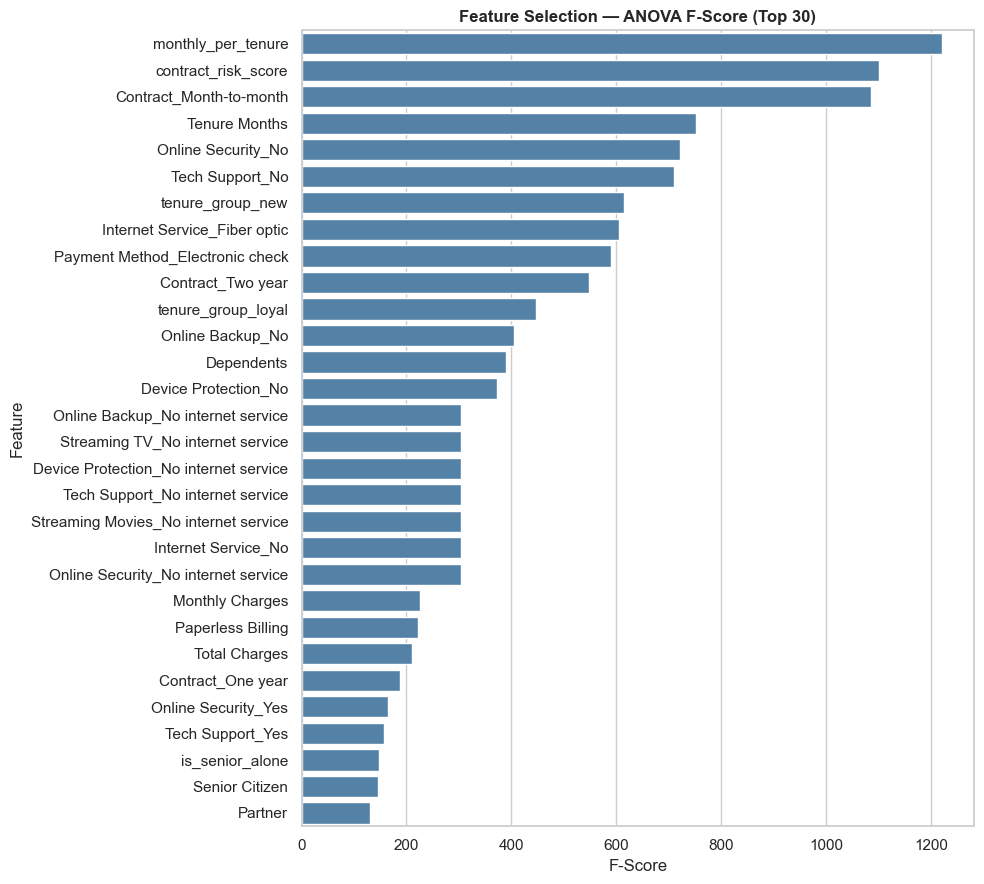

In [5]:
# Recuperando os nomes das features apos encoding para uso nos graficos
ohe_feature_names = (
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + ohe_feature_names

# SelectKBest com ANOVA F-value — seleciona as k features mais relevantes estatisticamente.
# Nota: aplicado APENAS apos o split, fitado somente no X_train (sem data leakage).
# O MLP (04_mlp.ipynb) usa todas as 49 features; aqui reduzimos para as 30 mais relevantes
# segundo o teste F univariado, o que reduz dimensionalidade e ruido para os modelos sklearn.
K_FEATURES = 30
selector = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_sel = selector.fit_transform(X_train_enc, y_train)
X_test_sel  = selector.transform(X_test_enc)

selected_mask     = selector.get_support()
selected_features = [name for name, keep in zip(all_feature_names, selected_mask) if keep]
feature_scores    = selector.scores_[selected_mask]

print(f"Features selecionadas ({K_FEATURES} de {X_train_enc.shape[1]}):\n")
score_df = (
    pd.DataFrame({"Feature": selected_features, "F-Score": feature_scores})
    .sort_values("F-Score", ascending=False)
    .reset_index(drop=True)
)
display(score_df)

# Grafico horizontal de importancia estatistica
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=score_df, x="F-Score", y="Feature", color="steelblue", ax=ax)
ax.set_title("Feature Selection — ANOVA F-Score (Top 30)", fontweight="bold")
ax.set_xlabel("F-Score")
plt.tight_layout()
plt.show()

# 🤖 5. Treinamento de Múltiplos Algoritmos

Nesta etapa, diferentes algoritmos de classificação serão treinados e avaliados nas mesmas features selecionadas, permitindo uma comparação justa entre abordagens distintas.

In [6]:
mlflow.set_experiment("telco-churn-model-engineering")

model_configs = {
    "Decision Tree":      DecisionTreeClassifier(random_state=RANDOM_SEED),
    "Random Forest":      RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "SVM":                SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED),
    "Gradient Boosting":  GradientBoostingClassifier(random_state=RANDOM_SEED),
}

trained_models = {}
results = []

for model_name, estimator in model_configs.items():
    with mlflow.start_run(run_name=model_name.lower().replace(" ", "-")):

        # Dataset version
        mlflow.log_input(mlflow_dataset, context="training")

        # SVM e sensivel a escala — ja esta no X_train_sel (StandardScaler aplicado)
        estimator.fit(X_train_sel, y_train)
        y_pred  = estimator.predict(X_test_sel)
        y_proba = estimator.predict_proba(X_test_sel)[:, 1]

        acc     = accuracy_score(y_test, y_pred)
        prec    = precision_score(y_test, y_pred)
        rec     = recall_score(y_test, y_pred)
        f1      = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc  = average_precision_score(y_test, y_proba)

        # Parametros e metricas (sem log_model nos runs de comparacao — artefato pesado)
        mlflow.log_param("model", model_name)
        mlflow.log_metrics({
            "accuracy":  acc,
            "precision": prec,
            "recall":    rec,
            "f1_score":  f1,
            "roc_auc":   roc_auc,
            "pr_auc":    pr_auc,
        })

        # Artefato: matriz de confusao
        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            display_labels=["No Churn", "Churn"],
            colorbar=False, ax=ax_cm,
        )
        ax_cm.set_title(f"{model_name} — Matriz de Confusao")
        plt.tight_layout()
        mlflow.log_figure(fig_cm, "confusion_matrix.png")
        plt.close(fig_cm)

        trained_models[model_name] = estimator
        results.append({
            "Modelo":    model_name,
            "Acuracia":  round(acc, 4),
            "Precisao":  round(prec, 4),
            "Recall":    round(rec, 4),
            "F1":        round(f1, 4),
            "ROC AUC":   round(roc_auc, 4),
            "PR AUC":    round(pr_auc, 4),
        })

        print(f"=== {model_name} ===")
        print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# Tabela de comparacao
results_df = pd.DataFrame(results).sort_values("ROC AUC", ascending=False).reset_index(drop=True)
print("\n=== COMPARACAO GERAL ===")
display(results_df)

=== Decision Tree ===
              precision    recall  f1-score   support

    No Churn       0.82      0.82      0.82      1031
       Churn       0.49      0.49      0.49       371

    accuracy                           0.73      1402
   macro avg       0.66      0.66      0.66      1402
weighted avg       0.73      0.73      0.73      1402

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1031
       Churn       0.63      0.49      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.71      1402
weighted avg       0.78      0.79      0.78      1402

=== SVM ===
              precision    recall  f1-score   support

    No Churn       0.85      0.91      0.88      1031
       Churn       0.68      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.73      0.74      1402
weighted avg      

,Modelo,Acuracia,Precisao,Recall,F1,ROC AUC,PR AUC
0,Gradient Boosting,0.8067,0.6613,0.5526,0.6021,0.8569,0.6726
1,Random Forest,0.7889,0.6307,0.4879,0.5502,0.8242,0.6051
2,SVM,0.8117,0.6814,0.5418,0.6036,0.8046,0.6252
3,Decision Tree,0.7325,0.4946,0.4906,0.4926,0.6549,0.3780


# ⚙️ 6. Tuning de Hiperparâmetros — Gradient Boosting

Nesta etapa, será realizado o ajuste de hiperparâmetros do modelo selecionado. A busca aleatória com orçamento de tempo (`ParameterSampler`) é utilizada em lugar do `GridSearch` exaustivo para explorar um espaço maior de combinações no mesmo tempo disponível.

In [7]:
# Busca aleatoria com orçamento de tempo (10 min)
# Hiperparametros-chave do GradientBoostingClassifier:
# n_estimators, max_depth, learning_rate, subsample, min_samples_split

TIME_LIMIT_MINUTES = 10
ROC_AUC_TARGET     = 0.86

start_time = time.time()
deadline   = start_time + TIME_LIMIT_MINUTES * 60

param_distributions = {
    "n_estimators":      randint(50, 500),
    "max_depth":         randint(2, 8),
    "learning_rate":     uniform(0.01, 0.2),
    "subsample":         uniform(0.6, 0.4),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf":  randint(1, 20),
}

sampler = ParameterSampler(param_distributions, n_iter=1_000_000, random_state=RANDOM_SEED)
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

best = {"params": None, "cv_roc": -np.inf, "test_roc": -np.inf, "model": None}
n_evaluated = 0

print(f"Iniciando busca por ate {TIME_LIMIT_MINUTES} min. Alvo: ROC AUC > {ROC_AUC_TARGET}")

for i, params in enumerate(sampler, start=1):
    if time.time() >= deadline:
        print("Tempo limite atingido.")
        break

    model = GradientBoostingClassifier(random_state=RANDOM_SEED, **params)

    cv_scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    mean_cv   = float(np.mean(cv_scores))

    model.fit(X_train_sel, y_train)
    y_proba   = model.predict_proba(X_test_sel)[:, 1]
    test_roc  = roc_auc_score(y_test, y_proba)

    if test_roc > best["test_roc"]:
        best.update({"params": params, "cv_roc": mean_cv, "test_roc": test_roc, "model": model})
        elapsed = time.time() - start_time
        print(f"[{i}] Novo melhor | ROC AUC teste={test_roc:.4f} | CV={mean_cv:.4f} | t={elapsed/60:.1f}m")

    if i % 10 == 0:
        elapsed   = time.time() - start_time
        remaining = max(0, deadline - time.time())
        print(f"Iter: {i} | melhor ROC AUC={best['test_roc']:.4f} | decorrido={elapsed/60:.1f}m | restante={remaining/60:.1f}m")

    n_evaluated = i

print(f"\nBusca concluida. Iteracoes avaliadas: {n_evaluated}")
print(f"Melhores parametros: {best['params']}")

Iniciando busca por ate 10 min. Alvo: ROC AUC > 0.86
[1] Novo melhor | ROC AUC teste=0.8485 | CV=0.8542 | t=0.1m
[2] Novo melhor | ROC AUC teste=0.8558 | CV=0.8641 | t=0.1m
Iter: 10 | melhor ROC AUC=0.8558 | decorrido=0.7m | restante=9.3m
[17] Novo melhor | ROC AUC teste=0.8569 | CV=0.8636 | t=1.0m
Iter: 20 | melhor ROC AUC=0.8569 | decorrido=1.1m | restante=8.9m
Iter: 30 | melhor ROC AUC=0.8569 | decorrido=1.7m | restante=8.3m
Iter: 40 | melhor ROC AUC=0.8569 | decorrido=2.4m | restante=7.6m
Iter: 50 | melhor ROC AUC=0.8569 | decorrido=3.0m | restante=7.0m
Iter: 60 | melhor ROC AUC=0.8569 | decorrido=3.6m | restante=6.4m
Iter: 70 | melhor ROC AUC=0.8569 | decorrido=4.3m | restante=5.7m
Iter: 80 | melhor ROC AUC=0.8569 | decorrido=5.0m | restante=5.0m
Iter: 90 | melhor ROC AUC=0.8569 | decorrido=5.7m | restante=4.3m
Iter: 100 | melhor ROC AUC=0.8569 | decorrido=6.5m | restante=3.5m
Iter: 110 | melhor ROC AUC=0.8569 | decorrido=7.2m | restante=2.8m
Iter: 120 | melhor ROC AUC=0.8569 | de

=== Gradient Boosting (Tunado) ===
ROC AUC : 0.8569
PR AUC  : 0.6685
F1-Score: 0.5976
Alvo ROC AUC > 0.86: nao atingido

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1031
       Churn       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



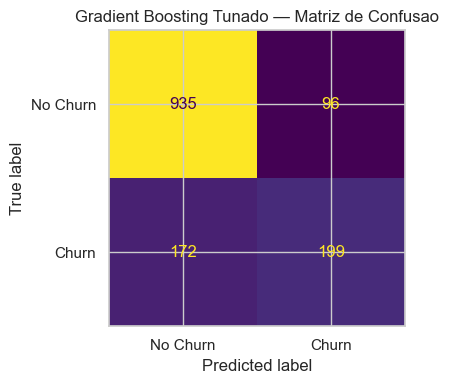

In [8]:
# Avaliacao final do modelo tunado
best_model  = best["model"]
y_pred_best = best_model.predict(X_test_sel)
y_prob_best = best_model.predict_proba(X_test_sel)[:, 1]

final_metrics = {
    "accuracy":  accuracy_score(y_test, y_pred_best),
    "precision": precision_score(y_test, y_pred_best),
    "recall":    recall_score(y_test, y_pred_best),
    "f1_score":  f1_score(y_test, y_pred_best),
    "roc_auc":   roc_auc_score(y_test, y_prob_best),
    "pr_auc":    average_precision_score(y_test, y_prob_best),
}

print("=== Gradient Boosting (Tunado) ===")
print(f"ROC AUC : {final_metrics['roc_auc']:.4f}")
print(f"PR AUC  : {final_metrics['pr_auc']:.4f}")
print(f"F1-Score: {final_metrics['f1_score']:.4f}")
print(f"Alvo ROC AUC > {ROC_AUC_TARGET}: {'ATINGIDO' if final_metrics['roc_auc'] > ROC_AUC_TARGET else 'nao atingido'}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))

# Matriz de confusao
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["No Churn", "Churn"],
    colorbar=False, ax=ax,
)
ax.set_title("Gradient Boosting Tunado — Matriz de Confusao")
plt.tight_layout()
plt.show()

# 📊 7. Feature Importance

Nesta etapa, serão analisadas as features mais relevantes para o modelo vencedor, utilizando dois métodos complementares: **importância por Gini** (rápida, baseada na estrutura da árvore) e **Permutation Importance** (mais confiável, baseada no impacto real na métrica).

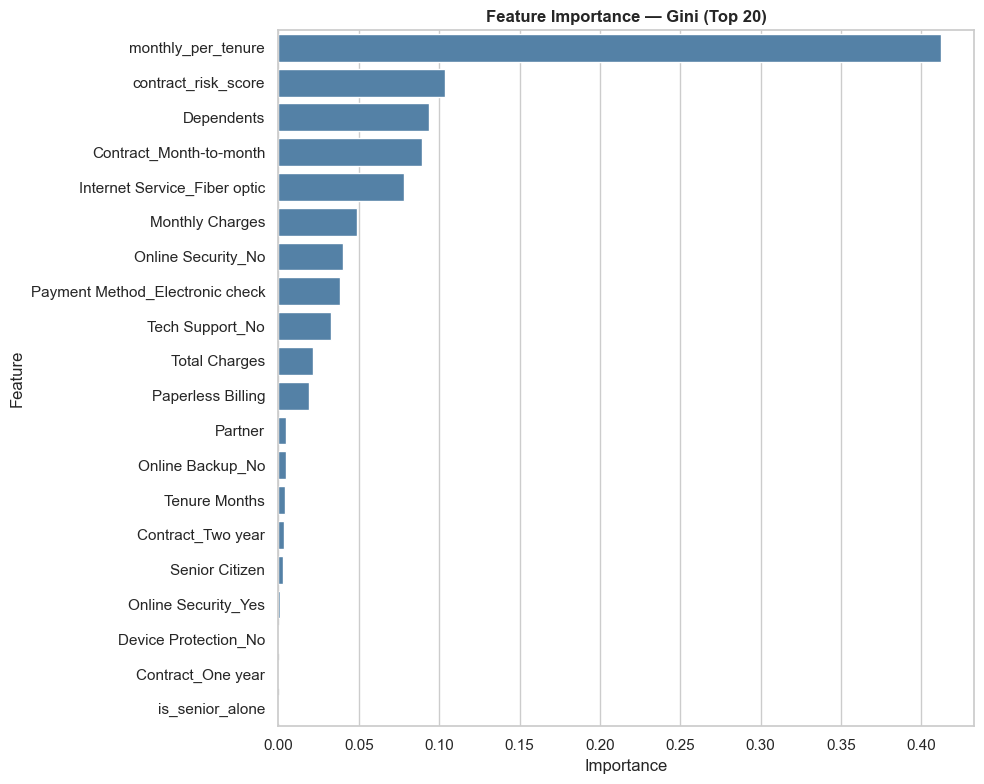

Top 10 features (Gini):


,Feature,Importance
0,monthly_per_tenure,0.412060
1,contract_risk_score,0.103898
2,Dependents,0.093618
3,Contract_Month-to-month,0.089474
4,Internet Service_Fiber optic,0.078192
5,Monthly Charges,0.048686
6,Online Security_No,0.040026
7,Payment Method_Electronic check,0.038227
8,Tech Support_No,0.032581
9,Total Charges,0.021450


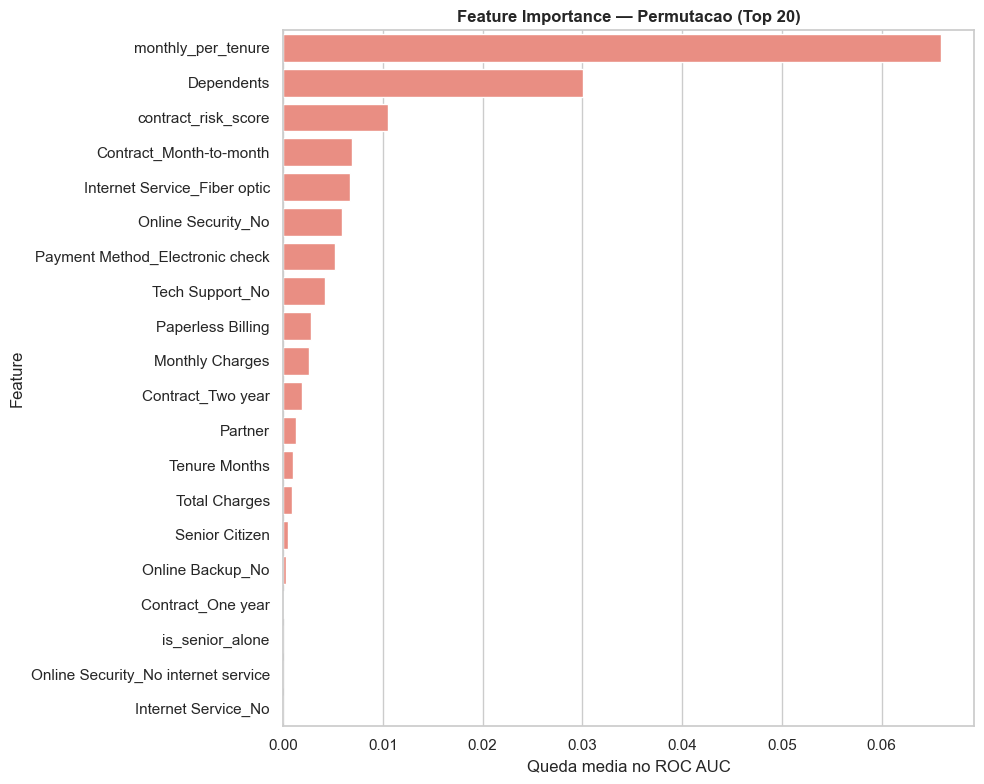

Top 10 features (Permutacao):


,Feature,Importance,Std
0,monthly_per_tenure,0.065965,0.005768
1,Dependents,0.030076,0.005872
2,contract_risk_score,0.010529,0.002756
3,Contract_Month-to-month,0.006921,0.002080
4,Internet Service_Fiber optic,0.006761,0.001205
5,Online Security_No,0.005947,0.002147
6,Payment Method_Electronic check,0.005174,0.001104
7,Tech Support_No,0.004216,0.001718
8,Paperless Billing,0.002791,0.001374
9,Monthly Charges,0.002644,0.001634


In [9]:
from sklearn.inspection import permutation_importance

# Nomes das features selecionadas pelo SelectKBest
selected_feature_names = [
    name for name, keep in zip(all_feature_names, selected_mask) if keep
]

# --- 1. Importancia baseada em arvore (Gini impurity) ---
gini_imp = best_model.feature_importances_
gini_df  = (
    pd.DataFrame({"Feature": selected_feature_names, "Importance": gini_imp})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=gini_df.head(20), x="Importance", y="Feature", color="steelblue", ax=ax)
ax.set_title("Feature Importance — Gini (Top 20)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 10 features (Gini):")
display(gini_df.head(10))

# --- 2. Importancia por permutacao (mais confiavel) ---
perm = permutation_importance(
    best_model, X_test_sel, y_test,
    scoring="roc_auc", n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1
)
perm_df = (
    pd.DataFrame({"Feature": selected_feature_names, "Importance": perm.importances_mean, "Std": perm.importances_std})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

fig2, ax2 = plt.subplots(figsize=(10, 8))
sns.barplot(data=perm_df.head(20), x="Importance", y="Feature", color="salmon", ax=ax2)
ax2.set_title("Feature Importance — Permutacao (Top 20)", fontweight="bold")
ax2.set_xlabel("Queda media no ROC AUC")
plt.tight_layout()
plt.show()

print("Top 10 features (Permutacao):")
display(perm_df.head(10))


# 💾 8. Persistência do Melhor Modelo

Nesta etapa, o melhor modelo, o pré-processador e o seletor de features serão salvos em disco e registrados no MLflow para rastreabilidade e uso futuro no pipeline de inferência.

In [10]:
# Salvando o melhor modelo, o preprocessador e o selector
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model,   "../models/best_model.joblib")
joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(selector,     "../models/feature_selector.pkl")

print("Artefatos salvos:")
print("  models/best_model.joblib      — Gradient Boosting tunado")
print("  models/preprocessor.pkl       — ColumnTransformer (scaler + encoder)")
print("  models/feature_selector.pkl   — SelectKBest (top 30 features)")

# Logando no MLflow
with mlflow.start_run(run_name="gradient-boosting-tuned-final"):
    # Dataset version
    mlflow.log_input(mlflow_dataset, context="training")

    # Parametros (hiperparametros otimizados + seed de reproducibilidade)
    mlflow.log_params({**best["params"], "random_seed": RANDOM_SEED})

    # Metricas — padronizadas com 03_mlp.ipynb (5 metricas identicas)
    mlflow.log_metrics(final_metrics)

    # Artefatos: modelo + preprocessador + selector + graficos
    mlflow.log_artifact("../models/best_model.joblib",    artifact_path="model")
    mlflow.sklearn.log_model(best_model, artifact_path="sklearn_model")  # registra o modelo no MLflow Model Registry
    mlflow.log_artifact("../models/preprocessor.pkl",     artifact_path="model")
    mlflow.log_artifact("../models/feature_selector.pkl", artifact_path="model")
    mlflow.log_figure(fig,  "feature_importance_gini.png")
    mlflow.log_figure(fig2, "feature_importance_permutation.png")
    print("\nRun logada no MLflow.")

2026/04/24 13:53:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 13:53:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Artefatos salvos:
  models/best_model.joblib      — Gradient Boosting tunado
  models/preprocessor.pkl       — ColumnTransformer (scaler + encoder)
  models/feature_selector.pkl   — SelectKBest (top 30 features)

Run logada no MLflow.


# 🏁 9. Benchmark dos Modelos Sklearn

Resultados consolidados de todos os modelos avaliados ate este estagio. A comparacao completa incluindo o modelo MLP (PyTorch) esta disponivel em `04_mlp.ipynb`.

> ¹ Dummy e Logistic Regression foram treinados no **notebook 02** (split 80/20, **sem** feature engineering — 19 features brutas). Os demais modelos usam split 80/20 com feature engineering (25 features) + SelectKBest (top-30 apos encoding).

| Modelo | ROC-AUC | PR-AUC | F1 | Recall | Observacao |
|--------|---------|--------|-----|--------|------------|
| Dummy Classifier ¹ | 0.50 | 0.2646 | 0.00 | 0.00 | Piso minimo |
| Decision Tree | 0.6549 | 0.3780 | 0.4926 | 0.49 | Sem ensemble |
| Random Forest | 0.8242 | 0.6051 | 0.5502 | 0.49 | Estavel, sem class_weight |
| SVM | 0.8046 | 0.6252 | 0.6036 | 0.54 | Boa precisao |
| Logistic Regression ¹ | 0.8543 | 0.6538 | 0.6223 | **0.77** | Maior Recall; class_weight=balanced |
| **Gradient Boosting (tunado)** | **0.8569** | **0.6685** | 0.5976 | 0.54 | **Maior ROC-AUC sklearn** |

**Proximo passo:** comparacao final com o MLP em `04_mlp.ipynb`.